In [18]:
import torch
import torch.nn as nn
import numpy as np

import matplotlib.pyplot as plt

In [19]:
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [20]:
class DenseNetwork(nn.Module):
    def __init__(self, layers, num_inputs=2, num_outputs=3):
        super().__init__()

        modules = []
        in_dim = num_inputs
        for h in layers:
            modules.append(nn.Linear(in_dim, h))
            modules.append(nn.Tanh())
            in_dim = h

        modules.append(nn.Linear(in_dim, num_outputs))
        self.net = nn.Sequential(*modules)

        # remove bias and set kaimimng normal with tanh nonlinearity
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="tanh")
                nn.init.zeros_(m.bias)

    def forward(self, xy):
        return self.net(xy)

In [46]:
LAYERS = (64, 64, 64, 64, 64, 64)

p_exit, gamma = 0.2, 1.4
x_throat, delta_throat = 0.5, 0.05
R_in_mult, R_end_mult = 2.0, 1.5
wall_delta = 0.05
# p_in, rho_in, u_in, v_in = 1.0, 1.0, 1.0, 1.0 (dimensionless)

# say, throat is midway, R_in is unit, R_out is 0.75 times that
rad_for_unit_area = 1 / np.sqrt(np.pi)

R_in, R_throat, R_out = (
    R_in_mult * rad_for_unit_area,
    x_throat * rad_for_unit_area,
    R_end_mult * rad_for_unit_area,
)

In [22]:
def generate_rad_space(x):
    if isinstance(x, torch.Tensor):
        conv = R_in - (R_in - R_throat) * (x / x_throat)
        divg = R_throat + (R_out - R_throat) * ((x - x_throat) / (1 - x_throat))
        return torch.where(x <= x_throat, conv, divg)
    x = np.atleast_1d(np.asarray(x, dtype=np.float64))
    radius = np.zeros_like(x)

    radius[x <= x_throat] = R_in - (R_in - R_throat) * (x[x <= x_throat] / x_throat)
    radius[x > x_throat] = R_throat + (R_out - R_throat) * (
        (x[x > x_throat] - x_throat) / (1 - x_throat)
    )
    return radius


def generate_rad_slope(x):
    slope_conv = -(R_in - R_throat) / x_throat
    slope_divg = (R_out - R_throat) / (1 - x_throat)

    if isinstance(x, torch.Tensor):
        return torch.where(
            x <= x_throat,
            torch.full_like(x, slope_conv),
            torch.full_like(x, slope_divg),
        )

    x = np.atleast_1d(np.asarray(x, dtype=np.float64))
    return np.where(x <= x_throat, slope_conv, slope_divg)


def generate_nozzle_points(
    N_interior=1000,
    N_inlet=100,
    N_outlet=100,
    N_wall=150,
    N_throat_wall=50,
    N_center=150,
):
    inlet_pts = torch.tensor(
        np.hstack([np.zeros((N_inlet, 1)), np.linspace(0, R_in, N_inlet)[:, None]]),
        dtype=torch.float32,
        requires_grad=True,
        device=device,
    )

    outlet_pts = torch.tensor(
        np.hstack([np.ones((N_outlet, 1)), np.linspace(0, R_out, N_outlet)[:, None]]),
        dtype=torch.float32,
        requires_grad=True,
        device=device,
    )

    center_pts = torch.tensor(
        np.hstack([np.linspace(0, 1, N_center)[:, None], np.zeros((N_center, 1))]),
        dtype=torch.float32,
        requires_grad=True,
        device=device,
    )

    wall_x = np.linspace(0, 1, N_wall)
    wall_pts = torch.tensor(
        np.hstack([wall_x[:, None], generate_rad_space(wall_x)[:, None]]),
        dtype=torch.float32,
        requires_grad=True,
        device=device,
    )

    throat_wall_x = np.linspace(
        x_throat - delta_throat, x_throat + delta_throat, N_throat_wall
    )
    throat_wall_pts = torch.tensor(
        np.hstack([throat_wall_x[:, None], generate_rad_space(throat_wall_x)[:, None]]),
        dtype=torch.float32,
        requires_grad=True,
        device=device,
    )

    random_interior_pts = np.random.rand(N_interior, 2)  # double, then filter
    wall_limits = generate_rad_space(random_interior_pts[:, 0])
    interior_pts = torch.tensor(
        np.hstack(
            [
                random_interior_pts[:, 0][:, None],
                (random_interior_pts[:, 1] * wall_limits)[:, None],
            ]
        ),
        dtype=torch.float32,
        requires_grad=True,
        device=device,
    )

    # Model expects a single tensor of shape [N, 2].
    points = torch.cat(
        [interior_pts, inlet_pts, outlet_pts, wall_pts, throat_wall_pts, center_pts],
        dim=0,
    )
    points.requires_grad_(True)
    return points

In [25]:
def d_(f, x):
    grad = torch.autograd.grad(
        f,
        x,
        grad_outputs=torch.ones_like(f),
        create_graph=True,
        allow_unused=True,
    )[0]
    if grad is None:
        return torch.zeros_like(x)
    return grad


def model_grads(model, xy):
    out = model(xy)
    psi = out[:, :1]
    p = out[:, 1:2]
    rho = out[:, 2:3]

    grad_psi = d_(psi, xy)
    u = grad_psi[:, 1:2]
    v = -grad_psi[:, 0:1]

    grad_u = d_(u, xy)
    grad_rho = d_(rho, xy)
    u_y = grad_u[:, 1:2]
    rho_y = grad_rho[:, 1:2]

    rho1u1 = rho * u
    rho1v1 = rho * v
    grad_rho1u1 = d_(rho1u1, xy)
    grad_rho1v1 = d_(rho1v1, xy)
    rho1u1_x = grad_rho1u1[:, :1]
    rho1v1_y = grad_rho1v1[:, 1:2]

    rho1u2 = rho1u1 * u
    rho1v2 = rho1v1 * v
    grad_rho1u2 = d_(rho1u2, xy)
    grad_rho1v2 = d_(rho1v2, xy)
    rho1u2_x = grad_rho1u2[:, :1]
    rho1v2_y = grad_rho1v2[:, 1:2]

    rho1u1v1 = rho1u1 * v
    grad_rho1u1v1 = d_(rho1u1v1, xy)
    rho1u1v1_x = grad_rho1u1v1[:, :1]
    rho1u1v1_y = grad_rho1u1v1[:, 1:2]

    grad_p = d_(p, xy)
    p_x = grad_p[:, :1]
    p_y = grad_p[:, 1:2]

    avg_rho1u2v2 = (rho1u2 + rho1v2) / 2
    u1avg_rho1u2v2 = u * avg_rho1u2v2
    v1avg_rho1u2v2 = v * avg_rho1u2v2
    grad_u1avg = d_(u1avg_rho1u2v2, xy)
    grad_v1avg = d_(v1avg_rho1u2v2, xy)
    u1avg_rho1u2v2_x = grad_u1avg[:, :1]
    v1avg_rho1u2v2_y = grad_v1avg[:, 1:2]

    u1p1 = u * p
    v1p1 = v * p
    grad_u1p1 = d_(u1p1, xy)
    grad_v1p1 = d_(v1p1, xy)
    u1p1_x = grad_u1p1[:, :1]
    v1p1_y = grad_v1p1[:, 1:2]

    return {
        "xy": xy,
        "u": u,
        "u_y": u_y,
        "v": v,
        "p": p,
        "rho": rho,
        "rho_y": rho_y,
        "rho1u1_x": rho1u1_x,
        "rho1v1_y": rho1v1_y,
        "rho1u2_x": rho1u2_x,
        "rho1v2_y": rho1v2_y,
        "rho1u1v1_x": rho1u1v1_x,
        "rho1u1v1_y": rho1u1v1_y,
        "p_x": p_x,
        "p_y": p_y,
        "u1avg_rho1u2v2_x": u1avg_rho1u2v2_x,
        "v1avg_rho1u2v2_y": v1avg_rho1u2v2_y,
        "u1p1_x": u1p1_x,
        "v1p1_y": v1p1_y,
    }

In [47]:
def pde_residuals(fields, gamma=1.4):
    rho1u1_x, rho1v1_y = fields["rho1u1_x"], fields["rho1v1_y"]
    rho1u2_x, rho1v2_y = fields["rho1u2_x"], fields["rho1v2_y"]
    rho1u1v1_x, rho1u1v1_y = fields["rho1u1v1_x"], fields["rho1u1v1_y"]
    p_x, p_y = fields["p_x"], fields["p_y"]
    u1p1_x, v1p1_y = fields["u1p1_x"], fields["v1p1_y"]
    u1avg_rho1u2v2_x, v1avg_rho1u2v2_y = (
        fields["u1avg_rho1u2v2_x"],
        fields["v1avg_rho1u2v2_y"],
    )

    mass = rho1u1_x + rho1v1_y
    mom_x = rho1u2_x + p_x + rho1u1v1_y
    mom_y = rho1u1v1_x + p_y + rho1v2_y
    energy = (
        (gamma / (gamma - 1)) * (u1p1_x + v1p1_y) + u1avg_rho1u2v2_x + v1avg_rho1u2v2_y
    )

    return mass, mom_x, mom_y, energy


def inlet_bd_residuals(fields):
    def filter_bd(arr, mask):
        arr = arr[mask]
        return 1.0 - arr

    xy, u, v, p, rho = (
        fields["xy"],
        fields["u"],
        fields["v"],
        fields["p"],
        fields["rho"],
    )

    inlet_mask = xy[:, 0:1] == 0.0
    u_inlet, p_inlet, rho_inlet = map(
        lambda arr: filter_bd(arr, inlet_mask), [u, p, rho]
    )
    return u_inlet, v[inlet_mask], p_inlet, rho_inlet


def wall_bd_residuals(fields):
    xy, u, v = fields["xy"], fields["u"], fields["v"]

    wall_profile = generate_rad_space(xy[:, 0:1])
    wall_slope = generate_rad_slope(xy[:, 0:1])
    wall_mask = xy[:, 1:2] >= wall_profile - wall_delta

    u_wall = u[wall_mask]
    v_wall = v[wall_mask]
    slope_wall = wall_slope[wall_mask]

    return v_wall - u_wall * slope_wall


def flow_guidance_residuals(fields, gamma=1.4):
    xy, u, v, p, rho = (
        fields["xy"],
        fields["u"],
        fields["v"],
        fields["p"],
        fields["rho"],
    )

    center_mask = torch.isclose(xy[:, 1:2], torch.zeros_like(xy[:, 1:2]), atol=1e-6)
    x_c = xy[:, 0:1][center_mask]
    if x_c.numel() == 0:
        z = torch.tensor(0.0, device=xy.device, dtype=xy.dtype)
        return z, z, z

    u_c = u[center_mask]
    v_c = v[center_mask]
    p_c = torch.clamp(p[center_mask], min=1e-8)
    rho_c = torch.clamp(rho[center_mask], min=1e-8)

    M_c = torch.sqrt(u_c**2 + v_c**2) / torch.sqrt(gamma * p_c / rho_c)

    throat_mask = torch.abs(x_c - x_throat) <= 0.03
    pre_mask = x_c < (x_throat - 0.02)
    post_mask = x_c > (x_throat + 0.02)

    zero = torch.tensor(0.0, device=xy.device, dtype=xy.dtype)

    throat_loss = (
        torch.mean((M_c[throat_mask] - 1.0) ** 2) if torch.any(throat_mask) else zero
    )
    pre_subsonic_loss = (
        torch.mean(torch.relu(M_c[pre_mask] - 1.0) ** 2) if torch.any(pre_mask) else zero
    )
    post_supersonic_loss = (
        torch.mean(torch.relu(1.0 - M_c[post_mask]) ** 2) if torch.any(post_mask) else zero
    )

    return throat_loss, pre_subsonic_loss, post_supersonic_loss


def exit_bd_residuals(fields):
    xy, p = fields["xy"], fields["p"]

    outlet_mask = xy[:, 0:1] == 1.0
    p_outlet = p[outlet_mask]

    return p_outlet - p_exit

In [48]:
def compute_loss(outputs, gamma=1.4):
    mass, mom_x, mom_y, energy = pde_residuals(outputs, gamma)
    inlet_u, inlet_v, inlet_p, inlet_rho = inlet_bd_residuals(outputs)
    wall_v = wall_bd_residuals(outputs)
    outlet_p = exit_bd_residuals(outputs)
    throat_loss, pre_sub_loss, post_sup_loss = flow_guidance_residuals(outputs, gamma)

    pde_loss = torch.mean(mass**2 + mom_x**2 + mom_y**2 + energy**2)
    inlet_loss = torch.mean(inlet_u**2 + inlet_v**2 + inlet_p**2 + inlet_rho**2)
    wall_loss = torch.mean(wall_v**2)
    outlet_loss = torch.mean(outlet_p**2)
    flow_guidance_loss = throat_loss + pre_sub_loss + post_sup_loss

    # Stronger PDE term plus isentropic consistency on centerline.
    total_loss = (
        6.0 * pde_loss
        + 0.6 * inlet_loss
        + 0.6 * wall_loss
        + 6.0 * outlet_loss
        + 2.0 * flow_guidance_loss
    )
    return total_loss, pde_loss, inlet_loss, wall_loss, outlet_loss, flow_guidance_loss

In [29]:
from typing import Optional
from pathlib import Path
from datetime import datetime
from copy import deepcopy
import os


class ModelSave:
    SAVE_DIR_NAME = "saved_models_pinn"

    def __init__(self):
        file = os.path.dirname(os.path.abspath("__file__"))
        self.save_dir = Path(file).joinpath(self.SAVE_DIR_NAME)
        self.save_dir.mkdir(exist_ok=True)

    def generate_save_path(self, suffix: Optional[str] = None) -> str:
        timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
        model_name = f"hybrid-qpinn-v2-{timestamp}"
        if suffix:
            model_name += f"-{suffix}"
        return str(self.save_dir.joinpath(model_name + ".pt"))

    @staticmethod
    def snapshot(model: nn.Module):
        return deepcopy(model.state_dict())

    @staticmethod
    def restore(model: nn.Module, snapshot: dict):
        model.load_state_dict(snapshot)

    @staticmethod
    def update_best(
        model: nn.Module,
        current_loss: float,
        best_loss: Optional[float],
        best_snapshot: Optional[dict],
    ):
        if best_loss is None or current_loss < best_loss:
            return current_loss, ModelSave.snapshot(model)
        return best_loss, best_snapshot

    @staticmethod
    def save(model: nn.Module, path: str):
        model_state = ModelSave.snapshot(model)

        torch.save(model_state, path)
        print(f"Model saved to {path}")

    @staticmethod
    def load(path: str):
        if not os.path.exists(path):
            raise FileNotFoundError(f"No model found at {path}")

        model = DenseNetwork(layers=LAYERS).to(device)
        model_state = torch.load(path, map_location=device)
        ModelSave.restore(model, model_state)
        print(f"Model loaded from {path}")
        return model

In [49]:
def train(
    model,
    gamma=1.4,
    adam_iters=10_000,
    lbfgs_iters=150,
    adam_lr=1e-3,
    model_manager=ModelSave(),
    print_every=250,
    resample_every=25,
):
    best_loss, best_state = float("inf"), None
    history = []

    adam = torch.optim.Adam(model.parameters(), lr=adam_lr)
    print("Starting Adam...")
    points = generate_nozzle_points()

    for i in range(adam_iters):
        if i % resample_every == 0:
            points = generate_nozzle_points()

        adam.zero_grad()

        outputs = model_grads(model, points)
        total_loss, pde_loss, inlet_loss, wall_loss, outlet_loss, flow_guidance_loss = (
            compute_loss(outputs, gamma)
        )

        best_loss, best_state = model_manager.update_best(
            model, total_loss.item(), best_loss, best_state
        )

        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        adam.step()

        if (i + 1) % print_every == 0:
            print(
                f"[Adam {i+1}/{adam_iters}] Total {total_loss.item():.2e}, PDE {pde_loss.item():.2e}, In: {inlet_loss.item():.2e}, Wall: {wall_loss.item():.2e}, Out: {outlet_loss.item():.2e}, flow: {flow_guidance_loss.item():.2e}"
            )
            history.append(
                (
                    total_loss.item(),
                    pde_loss.item(),
                    inlet_loss.item(),
                    flow_guidance_loss.item(),
                    wall_loss.item(),
                    outlet_loss.item(),
                )
            )

    if best_state is not None:
        model_manager.restore(model, best_state)
    print("[Adam] Optimizer ran.", end=" ")
    save_path = model_manager.generate_save_path(suffix="post-adam")
    # model_manager.save(model, save_path)
    print(f"[Adam] Model saved to {save_path}.")

    params = [p for p in model.parameters() if p.requires_grad]
    lbfgs = torch.optim.LBFGS(
        params, max_iter=lbfgs_iters, line_search_fn="strong_wolfe"
    )

    def lbfgs_closure():
        model.zero_grad()
        outputs = model_grads(model, points)
        total_loss, _, _, _, _, _ = compute_loss(outputs, gamma)
        total_loss.backward()
        return total_loss

    print("Starting L-BFGS...")
    for i in range(lbfgs_iters):
        total_loss = lbfgs.step(lbfgs_closure)
        loss_value = float(total_loss.detach().item())
        best_loss, best_state = ModelSave.update_best(
            model, loss_value, best_loss, best_state
        )

        history.append((loss_value,))
        if (i + 1) % print_every == 0:
            print(f"[L-BFGS {i+1}/{lbfgs_iters}] Total: {loss_value:.3e}")

    if best_state is not None:
        model_manager.restore(model, best_state)
    print("[L-BFGS] Optimizer ran.", end=" ")
    save_path = model_manager.generate_save_path(suffix="post-lbfgs")
    model_manager.save(model, save_path)
    print(f"[L-BFGS] Model saved to {save_path}.")

    return history

In [50]:
model = DenseNetwork(layers=LAYERS).to(device)

{
    "total params": sum(p.numel() for p in model.parameters()),
    "trainable params": sum(p.numel() for p in model.parameters() if p.requires_grad),
}

{'total params': 21187, 'trainable params': 21187}

In [ ]:
loss_history = train(model, gamma=gamma)

Starting Adam...
[Adam 100/600] Total 9.54e-01, PDE 1.22e-02, In: 1.43e+00, Wall: 3.96e-02, Out: 3.85e-04, flow: 3.14e-02, iso: 9.43e-03, accel: 8.95e-03
[Adam 200/600] Total 7.42e-01, PDE 1.20e-02, In: 1.18e+00, Wall: 8.56e-02, Out: 5.14e-04, flow: 4.14e-04, iso: 4.74e-03, accel: 0.00e+00


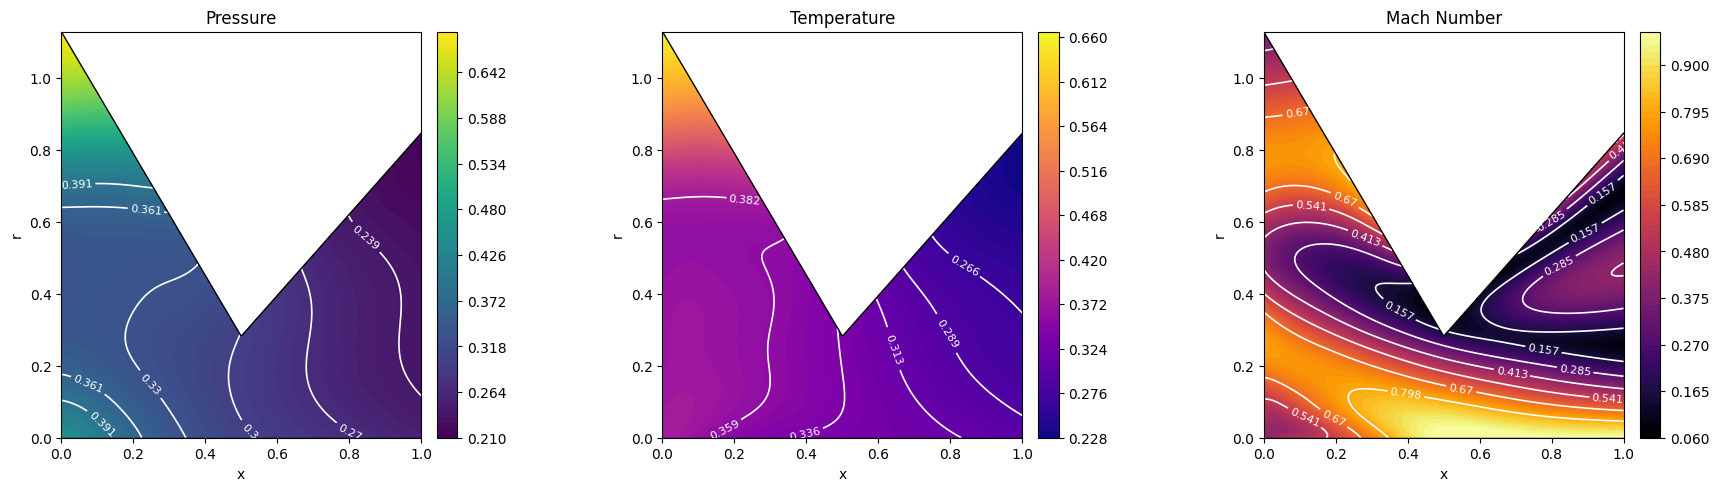

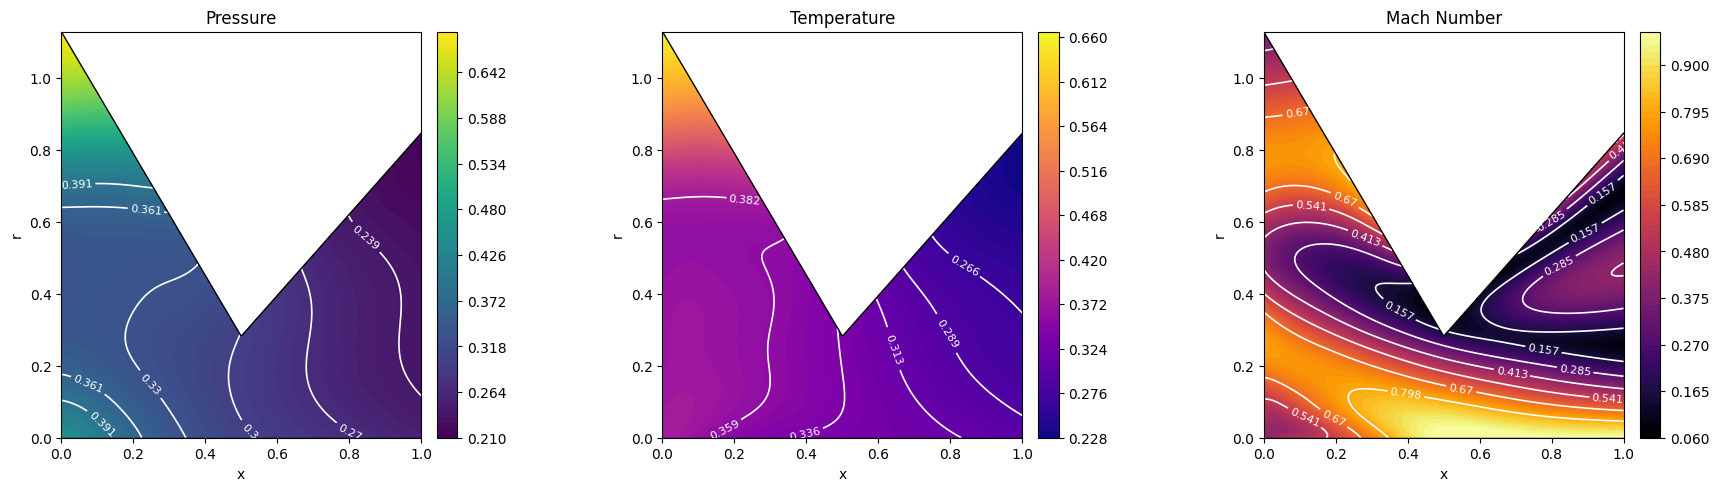

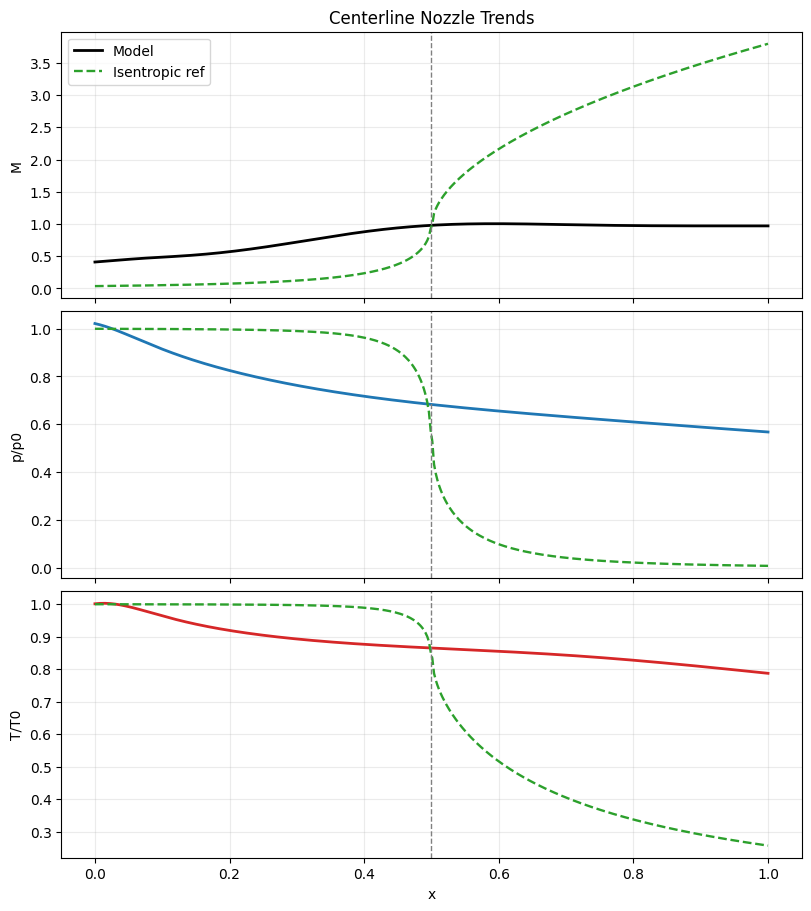

In [45]:
model.eval()

Nx, Ny = 320, 220
x_vals = np.linspace(0.0, 1.0, Nx)
y_vals = np.linspace(0.0, max(R_in, R_out), Ny)
X, Y = np.meshgrid(x_vals, y_vals)

R_wall = generate_rad_space(X)
inside_mask = Y <= R_wall

xy_inside = np.column_stack((X[inside_mask], Y[inside_mask]))
xy_inside_t = torch.tensor(
    xy_inside, dtype=torch.float32, device=device, requires_grad=True
)

pred = model(xy_inside_t)
psi = pred[:, :1]
p = pred[:, 1:2]
rho = pred[:, 2:3]

grad_psi = torch.autograd.grad(
    psi,
    xy_inside_t,
    grad_outputs=torch.ones_like(psi),
    create_graph=False,
    retain_graph=False,
)[0]

u = grad_psi[:, 1:2]
v = -grad_psi[:, 0:1]

p_np = p.detach().cpu().numpy().ravel()
rho_np = rho.detach().cpu().numpy().ravel()
u_np = u.detach().cpu().numpy().ravel()
v_np = v.detach().cpu().numpy().ravel()

rho_safe = np.clip(rho_np, 1e-8, None)
p_safe = np.clip(p_np, 1e-8, None)
T_np = p_safe / rho_safe
vel_mag = np.sqrt(u_np**2 + v_np**2)
a_np = np.sqrt(np.clip(gamma * p_safe / rho_safe, 1e-12, None))
M_np = vel_mag / a_np

P_grid = np.full_like(X, np.nan, dtype=float)
T_grid = np.full_like(X, np.nan, dtype=float)
M_grid = np.full_like(X, np.nan, dtype=float)

P_grid[inside_mask] = p_np
T_grid[inside_mask] = T_np
M_grid[inside_mask] = M_np

fig, axs = plt.subplots(1, 3, figsize=(18, 4.8), constrained_layout=True)
plots = [
    (P_grid, "Pressure", "viridis"),
    (T_grid, "Temperature", "plasma"),
    (M_grid, "Mach Number", "inferno"),
]

specific_levels = {
    "Pressure": [0.2, 0.4, 0.6, 0.8, 1.0],
    "Temperature": [0.2, 0.4, 0.6, 0.8, 1.0],
    "Mach Number": [0.2, 0.5, 0.8, 1.0, 1.2],
}

wall_profile = generate_rad_space(x_vals)
for ax, (field, title, cmap) in zip(axs, plots):
    valid = field[np.isfinite(field)]
    if title == "Mach Number":
        # Prevent a few outliers from collapsing the visible colormap.
        vmax = np.percentile(valid, 99)
        field = np.minimum(field, vmax)
        valid = field[np.isfinite(field)]

    contour = ax.contourf(X, Y, field, levels=80, cmap=cmap)

    req_levels = np.array(specific_levels[title], dtype=float)
    if req_levels.min() >= valid.min() and req_levels.max() <= valid.max():
        line_levels = req_levels
    else:
        level_min, level_max = np.percentile(valid, [10, 90])
        line_levels = np.linspace(level_min, level_max, 6)

    lines = ax.contour(X, Y, field, levels=line_levels, colors="white", linewidths=1.2)
    ax.clabel(lines, inline=True, fmt="%.3g", fontsize=8)

    ax.plot(x_vals, wall_profile, color="black", lw=1.0)
    ax.plot(x_vals, np.zeros_like(x_vals), color="black", lw=1.0)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("r")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, max(R_in, R_out))
    ax.set_aspect("equal", adjustable="box")
    fig.colorbar(contour, ax=ax, pad=0.01)

plt.show()


def area_mach_ratio(M, gamma_val):
    return (
        (1.0 / M)
        * ((2.0 / (gamma_val + 1.0)) * (1.0 + 0.5 * (gamma_val - 1.0) * M**2))
        ** ((gamma_val + 1.0) / (2.0 * (gamma_val - 1.0)))
    )


def solve_mach_for_area(A_by_Astar, gamma_val, supersonic):
    if np.isclose(A_by_Astar, 1.0, atol=1e-6):
        return 1.0

    lo, hi = (1.0001, 8.0) if supersonic else (1e-4, 0.9999)
    f_lo = area_mach_ratio(lo, gamma_val) - A_by_Astar
    f_hi = area_mach_ratio(hi, gamma_val) - A_by_Astar

    if f_lo * f_hi > 0:
        return lo if abs(f_lo) < abs(f_hi) else hi

    for _ in range(80):
        mid = 0.5 * (lo + hi)
        f_mid = area_mach_ratio(mid, gamma_val) - A_by_Astar
        if abs(f_mid) < 1e-10:
            return mid
        if f_lo * f_mid < 0:
            hi = mid
            f_hi = f_mid
        else:
            lo = mid
            f_lo = f_mid
    return 0.5 * (lo + hi)


# Centerline comparison: model vs quasi-1D isentropic reference.
x_center = np.linspace(0.0, 1.0, 400)
y_center = np.zeros_like(x_center)
xy_center_t = torch.tensor(
    np.column_stack((x_center, y_center)),
    dtype=torch.float32,
    device=device,
    requires_grad=True,
)

pred_c = model(xy_center_t)
psi_c = pred_c[:, :1]
p_c = pred_c[:, 1:2]
rho_c = pred_c[:, 2:3]

grad_psi_c = torch.autograd.grad(
    psi_c,
    xy_center_t,
    grad_outputs=torch.ones_like(psi_c),
    create_graph=False,
    retain_graph=False,
)[0]

u_c = grad_psi_c[:, 1:2]
v_c = -grad_psi_c[:, 0:1]

p_c = np.clip(p_c.detach().cpu().numpy().ravel(), 1e-8, None)
rho_c = np.clip(rho_c.detach().cpu().numpy().ravel(), 1e-8, None)
vel_c = np.sqrt(
    u_c.detach().cpu().numpy().ravel() ** 2 + v_c.detach().cpu().numpy().ravel() ** 2
)
T_c = p_c / rho_c
a_c = np.sqrt(np.clip(gamma * p_c / rho_c, 1e-12, None))
M_c = vel_c / a_c

# Use inlet average for stable normalization.
inlet_slice = slice(0, max(5, len(p_c) // 20))
p0 = float(np.mean(p_c[inlet_slice]))
T0 = float(np.mean(T_c[inlet_slice]))

A = np.pi * (generate_rad_space(x_center) ** 2)
A_by_Astar = A / np.min(A)
M_ref = np.array([
    solve_mach_for_area(a, gamma, supersonic=(x > x_throat))
    for x, a in zip(x_center, A_by_Astar)
])
p_ref = (1.0 + 0.5 * (gamma - 1.0) * M_ref**2) ** (-gamma / (gamma - 1.0))
T_ref = (1.0 + 0.5 * (gamma - 1.0) * M_ref**2) ** (-1.0)

fig2, ax2 = plt.subplots(3, 1, figsize=(8, 9), sharex=True, constrained_layout=True)

ax2[0].plot(x_center, M_c, color="black", lw=2.0, label="Model")
ax2[0].plot(x_center, M_ref, color="tab:green", lw=1.7, ls="--", label="Isentropic ref")
ax2[0].axvline(x_throat, color="gray", ls="--", lw=1.0)
ax2[0].set_ylabel("M")
ax2[0].set_title("Centerline Nozzle Trends")
ax2[0].legend(loc="best")

ax2[1].plot(x_center, p_c / p0, color="tab:blue", lw=2.0, label="Model")
ax2[1].plot(x_center, p_ref, color="tab:green", lw=1.7, ls="--", label="Isentropic ref")
ax2[1].axvline(x_throat, color="gray", ls="--", lw=1.0)
ax2[1].set_ylabel("p/p0")

ax2[2].plot(x_center, T_c / T0, color="tab:red", lw=2.0, label="Model")
ax2[2].plot(x_center, T_ref, color="tab:green", lw=1.7, ls="--", label="Isentropic ref")
ax2[2].axvline(x_throat, color="gray", ls="--", lw=1.0)
ax2[2].set_ylabel("T/T0")
ax2[2].set_xlabel("x")

for a in ax2:
    a.grid(alpha=0.25)

plt.show()